Saving academia_redfit.csv to academia_redfit (16).csv
Dataset carregado: 1000 alunos e 12 colunas
Valores nulos por coluna:
idade                         0
sexo                          0
frequencia_semanal_treino    51
tipo_atividade                0
tempo_medio_exercicio        46
minutos_totais_semana        95
preco_plano                   0
possui_nutricionista          0
primeiro_PGC                  0
ultimo_PGC                    0
data_matricula                0
estado                        0
dtype: int64
Nulos corrigidos!
idade                        0
sexo                         0
frequencia_semanal_treino    0
tipo_atividade               0
tempo_medio_exercicio        0
minutos_totais_semana        0
preco_plano                  0
possui_nutricionista         0
primeiro_PGC                 0
ultimo_PGC                   0
data_matricula               0
estado                       0
dtype: int64
Coluna criada! Veja os primeiros valores:
0    14.6
1     1.7
2    15.8
3  

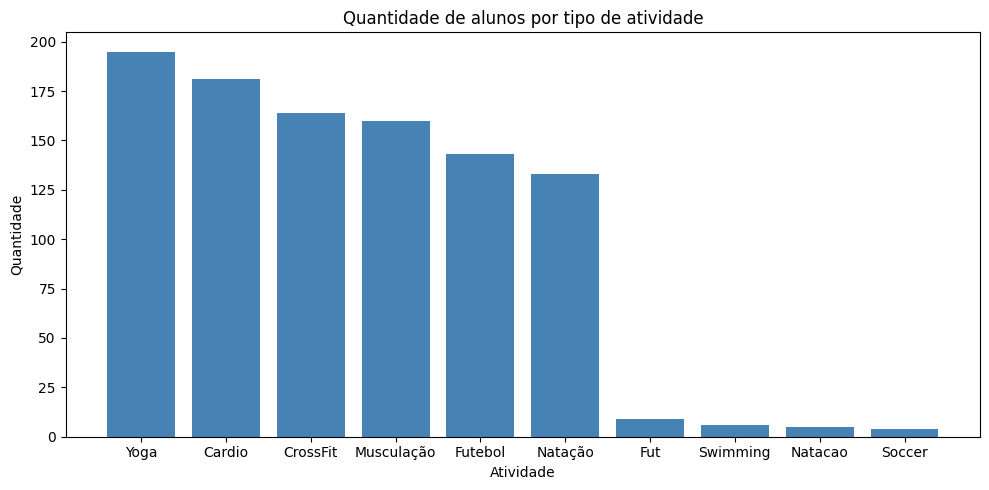

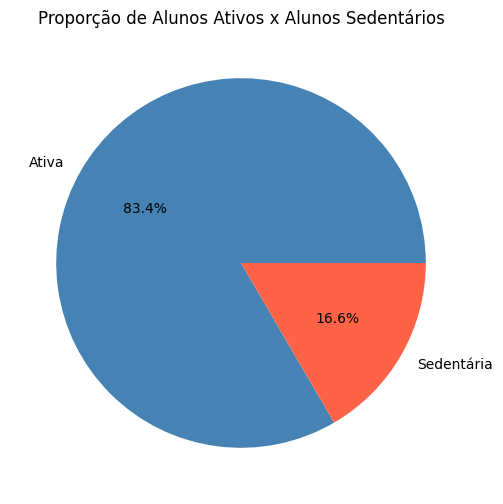

Treino: 800 alunos
Teste: 200 alunos
Acurácia do modelo: 93.50%


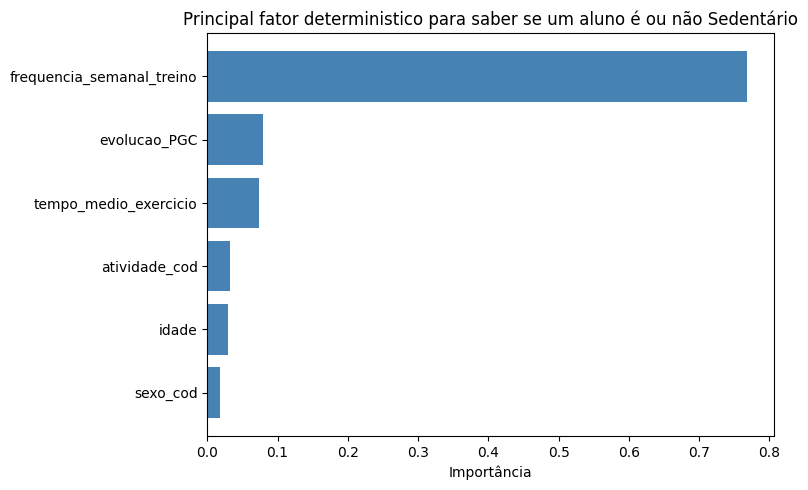

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from google.colab import files

uploaded = files.upload()

df = pd.read_csv('academia_redfit.csv')
print(f"Dataset carregado: {df.shape[0]} alunos e {df.shape[1]} colunas")
df.head()

print("Valores nulos por coluna:")
print(df.isnull().sum())

df['frequencia_semanal_treino'] = df['frequencia_semanal_treino'].fillna(df['frequencia_semanal_treino'].median())
df['tempo_medio_exercicio'] = df['tempo_medio_exercicio'].fillna(df['tempo_medio_exercicio'].median())
df['minutos_totais_semana'] = df['minutos_totais_semana'].fillna(df['minutos_totais_semana'].median())

print("Nulos corrigidos!")
print(df.isnull().sum())

df['evolucao_PGC'] = df['primeiro_PGC'] - df['ultimo_PGC']

print("Coluna criada! Veja os primeiros valores:")
print(df['evolucao_PGC'].head())

contagem = df['tipo_atividade'].value_counts()

plt.figure(figsize=(10, 5))
plt.bar(contagem.index, contagem.values, color='steelblue')
plt.title('Quantidade de alunos por tipo de atividade')
plt.xlabel('Atividade')
plt.ylabel('Quantidade')
plt.tight_layout()
plt.show()

contagem_estado = df['estado'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(contagem_estado.values, labels=contagem_estado.index, autopct='%1.1f%%', colors=['steelblue', 'tomato'])
plt.title('Proporção de Alunos Ativos x Alunos Sedentários')
plt.show()

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['sexo_cod'] = le.fit_transform(df['sexo'])
df['atividade_cod'] = le.fit_transform(df['tipo_atividade'])
df['estado_cod'] = le.fit_transform(df['estado'])

X = df[['idade', 'frequencia_semanal_treino', 'tempo_medio_exercicio', 'evolucao_PGC', 'sexo_cod', 'atividade_cod']]
y = df['estado_cod']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Treino: {X_train.shape[0]} alunos")
print(f"Teste: {X_test.shape[0]} alunos")

modelo = RandomForestClassifier(n_estimators=50, max_depth=3, max_features=2, random_state=42)
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

acuracia = accuracy_score(y_test, y_pred)
print(f"Acurácia do modelo: {acuracia:.2%}")

importancias = pd.Series(modelo.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(8, 5))
plt.barh(importancias.index, importancias.values, color='steelblue')
plt.title('Principal fator deterministico para saber se um aluno é ou não Sedentário')
plt.xlabel('Importância')
plt.tight_layout()
plt.show()

df.to_csv('academia_redfit_limpo.csv', index=False)
files.download('academia_redfit_limpo.csv')